# ECOM Solar Radiation Pressure

Solar radiation pressure (SRP) is the largest non-gravitational force on a GNSS satellite, and the hardest to model physically: it depends on the spacecraft's shape, surface properties, thermal state and attitude law. The **Empirical CODE Orbit Model (ECOM)** sidesteps all of that by writing the SRP acceleration in a Sun-oriented satellite frame as a small set of constant and once-per-revolution coefficients that are *estimated* from tracking data rather than derived from a surface model. It is what CODE and most IGS analysis centres use for precise GNSS orbits.

This tutorial

1. downloads a month of IGS final GPS orbits (SP3) for one satellite,
2. fits an initial state plus ECOM coefficients to the first three days with `scipy.optimize.least_squares`,
3. propagates forward with the fitted coefficients and measures the error against the SP3 truth for the cannonball model, the reduced 5-parameter ECOM, and the 9-parameter ECOM2.

The model, the DYB frame, the sign and eclipse conventions, and the parameter sets are described in the [Force Model guide](../guide/forces.md#empirical-code-orbit-model-ecom); the API is [`satkit.ecomparams`](../api/satprop.md#satkit.ecomparams). In short: with $\hat e_D$ pointing from the satellite **to the Sun**, $\hat e_Y = \hat e_D \times \hat r$ along the solar-panel axis and $\hat e_B = \hat e_D \times \hat e_Y$,

$$\vec a = \nu\,D(\varphi)\,\hat e_D + Y(\varphi)\,\hat e_Y + \nu\,B(\varphi)\,\hat e_B$$

where $\nu$ is the Earth-shadow factor, $\varphi$ is the argument of latitude $u$ (ECOM1) or $\Delta u$ from orbit noon (ECOM2), and the physical $D_0$ is *negative*, about $-10^{-7}$ m/s² for a GPS satellite.

**Runtime and data.** The fits below take a few seconds to a minute each (finite-difference Jacobians over a few hundred propagations), and the data are ~32 daily files (~1 MB each) fetched from BKG's public IGS mirror. The notebook is committed with its outputs and is not re-executed by the documentation build.


In [1]:
import datetime as dt
import gzip
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import requests
from scipy.optimize import least_squares

import satkit as sk

PRN = 20                      # GPS satellite (PRN G20)
START = dt.date(2024, 1, 1)   # first day of the window
FIT_DAYS = 3                  # length of the fit arc
PROP_DAYS = 30                # length of the prediction
CACHE = Path(os.environ.get("SP3_CACHE", "sp3-cache"))  # where SP3 files are kept

## Truth: IGS final orbits

The IGS final combined product gives satellite centre-of-mass positions in the ITRF every 15 minutes, accurate to ~2.5 cm. Daily files are named `IGS0OPSFIN_<year><doy>0000_01D_15M_ORB.SP3` under the GPS-week directory on the BKG mirror (no login required). We read one PRN, drop any flagged epochs, and rotate the positions into the GCRF with the full IAU 2006/2000A transform — the frame in which `satkit.propagate` works.

In [2]:
GPS_EPOCH = dt.date(1980, 1, 6)
BKG = "https://igs.bkg.bund.de/root_ftp/IGS/products"


def fetch_sp3(day: dt.date) -> Path:
    """Download (once) the IGS final SP3 for `day` into CACHE."""
    doy = day.timetuple().tm_yday
    name = f"IGS0OPSFIN_{day.year}{doy:03d}0000_01D_15M_ORB.SP3"
    out = CACHE / name
    if not out.exists():
        week = (day - GPS_EPOCH).days // 7
        r = requests.get(f"{BKG}/{week}/{name}.gz", timeout=120)
        r.raise_for_status()
        CACHE.mkdir(parents=True, exist_ok=True)
        out.write_bytes(gzip.decompress(r.content))
    return out


def read_sp3(path: Path, prn: int):
    """(times, ITRF positions in m) for one GPS PRN; bad epochs dropped."""
    times, pos, current = [], [], None
    for line in open(path):
        if line.startswith("*"):
            y, mo, d, h, mi = int(line[3:7]), int(line[8:10]), int(line[11:13]), int(line[14:16]), int(line[17:19])
            current = sk.time(y, mo, d, h, mi, float(line[20:31]))
        elif line.startswith(f"PG{prn:02d}") and current is not None:
            x, y_, z = float(line[4:18]), float(line[18:32]), float(line[32:46])
            if any(abs(v) > 900000.0 for v in (x, y_, z)) or (x == 0.0 and y_ == 0.0):
                continue
            times.append(current)
            pos.append([x, y_, z])
    return times, np.array(pos) * 1e3


def load_truth(start: dt.date, ndays: int, prn: int):
    """Concatenate daily files into GCRF truth (times, positions in m)."""
    times, pos = [], []
    for i in range(ndays):
        t, p = read_sp3(fetch_sp3(start + dt.timedelta(days=i)), prn)
        for tt, pp in zip(t, p):
            if times and tt == times[-1]:  # duplicate day-boundary epoch
                continue
            times.append(tt)
            pos.append(pp)
    pos = np.array(pos)
    gcrf = np.array([sk.frametransform.qitrf2gcrf(t) * p for t, p in zip(times, pos)])
    return times, gcrf


times, truth = load_truth(START, PROP_DAYS + 1, PRN)
n_fit = sum(1 for t in times if t <= times[0] + sk.duration.from_days(FIT_DAYS))
print(f"G{PRN:02d}: {len(times)} epochs, {times[0]} → {times[-1]}; fitting on the first {n_fit}")

# Is this an eclipse season for this satellite? (cylindrical shadow test)
in_shadow = 0
for t, p in zip(times, truth):
    s_hat = sk.sun.pos_gcrf(t)
    s_hat = s_hat / np.linalg.norm(s_hat)
    along = p @ s_hat
    if along < 0 and np.linalg.norm(p - along * s_hat) < sk.consts.earth_radius:
        in_shadow += 1
print(f"epochs in Earth shadow: {in_shadow} ({'eclipse season' if in_shadow else 'none — no eclipses in this window'})")

G20: 2976 epochs, 2024-01-01T00:00:00.000000Z → 2024-01-31T23:45:00.000000Z; fitting on the first 289
epochs in Earth shadow: 0 (none — no eclipses in this window)


## Force model and SRP variants

Everything except SRP is the same for all three variants: EGM96 to degree and order 12 (more than enough at 26,600 km), Sun and Moon, solid Earth tides, relativity. The variants differ only in the `satproperties` passed to `propagate`:

| variant | free coefficients | `satproperties` |
|---|---|---|
| cannonball | $C_R A/m$ (m²/kg) | `satproperties(craoverm=c)` |
| ECOM reduced | $D_0, Y_0, B_0, B_c, B_s$ (m/s²) | `satproperties(craoverm=0, ecom=ecomparams.reduced(...))` |
| ECOM2 | $D_0, Y_0, B_0, B_{1c}, B_{1s}, D_{2c}, D_{2s}, D_{4c}, D_{4s}$ | `satproperties(craoverm=0, ecom=ecomparams.ecom2(...))` |

`craoverm=0` makes ECOM the *whole* SRP model rather than a correction on top of the cannonball. Coefficients are handled in nm/s² inside the fit so that all parameters are O(1–100).

In [3]:
settings = sk.propsettings()
settings.gravity_degree = 12
settings.gravity_order = 12
settings.use_sun_gravity = True
settings.use_moon_gravity = True
settings.tide_model = sk.tidemodel.solid_step1
settings.use_relativistic_correction = True
settings.use_spaceweather = False      # no drag at GPS altitude
settings.abs_error = settings.rel_error = 1e-11
settings.enable_interp = True          # so one propagation can be sampled at every SP3 epoch

# name: (initial coefficients, finite-difference step, builder from coefficients)
VARIANTS = {
    "cannonball": ([0.02], [1e-2], lambda c: sk.satproperties(craoverm=c[0])),
    "ecom-reduced": (
        [-100.0, 0, 0, 0, 0], [0.1] * 5,
        lambda c: sk.satproperties(craoverm=0.0, ecom=sk.ecomparams.reduced(*(np.asarray(c) * 1e-9))),
    ),
    "ecom2": (
        [-100.0] + [0.0] * 8, [0.1] * 9,
        lambda c: sk.satproperties(craoverm=0.0, ecom=sk.ecomparams.ecom2(*(np.asarray(c) * 1e-9))),
    ),
}


def propagate_states(x, build, t0, t1, at_times):
    """Propagate [x,y,z (km), vx,vy,vz (m/s), coeffs...] and sample at `at_times`."""
    state = np.concatenate((x[:3] * 1e3, x[3:6]))
    res = sk.propagate(state, t0, t1, propsettings=settings, satproperties=build(x[6:]))
    return np.array(res.interp(at_times))

## Fit: initial state + SRP coefficients

The unknowns are the GCRF state at the first epoch (position in km, velocity in m/s, so the parameters are similarly scaled) and the SRP coefficients. The residual is the propagated-minus-truth position at every SP3 epoch in the fit arc; `least_squares` builds a finite-difference Jacobian, so each iteration costs one propagation per parameter.

Two practical details: the initial velocity is seeded by differencing the first two truth points, and the finite-difference steps are set explicitly — scipy's default relative step on a coefficient whose current value is *zero* is far below the integrator's noise floor.

In [4]:
def fit(variant):
    c0, dstep, build = VARIANTS[variant]
    tf, pf = times[:n_fit], truth[:n_fit]
    v0 = (pf[1] - pf[0]) / (tf[1] - tf[0]).seconds
    x0 = np.concatenate((pf[0] / 1e3, v0, c0))

    def resid(x):
        return (propagate_states(x, build, tf[0], tf[-1], tf)[:, :3] - pf).ravel()

    sol = least_squares(resid, x0, x_scale="jac", diff_step=[1e-6] * 6 + dstep, max_nfev=400)
    return sol.x, np.sqrt(np.mean(sol.fun**2))


fits = {}
for name in VARIANTS:
    x, rms = fit(name)
    fits[name] = x
    unit = "m²/kg" if name == "cannonball" else "nm/s²"
    print(f"{name:13s} fit RMS {rms:6.3f} m   coefficients ({unit}): "
          + ", ".join(f"{c:8.3f}" for c in x[6:]))

cannonball    fit RMS  2.341 m   coefficients (m²/kg):    0.023


ecom-reduced  fit RMS  0.129 m   coefficients (nm/s²): -105.785,    1.032,   -3.176,    1.182,    0.341


ecom2         fit RMS  0.128 m   coefficients (nm/s²): -106.146,    1.050,   -3.171,   -0.209,    1.768,   -1.956,   -3.586,    1.930,   -0.709


The reduced-ECOM and ECOM2 fits are ~20× tighter than the cannonball's, and the coefficients are physical: $D_0 \approx -106$ nm/s² is the expected $-P_\odot\,C_R A/m$ for $C_R A/m \approx 0.023$ m²/kg (which is what the cannonball fit found), and the Y and B terms are a few nm/s².

## Prediction: propagate a month with the fitted coefficients

From each fitted state and coefficient set, propagate over the whole window in one call and compare with the truth at every epoch. The RTN decomposition tells us *where* the error goes.

In [5]:
def rtn(pos, vel, d):
    r_hat = pos / np.linalg.norm(pos)
    n_hat = np.cross(pos, vel); n_hat /= np.linalg.norm(n_hat)
    return np.array([d @ r_hat, d @ np.cross(n_hat, r_hat), d @ n_hat])


tdays = np.array([(t - times[0]).days for t in times])  # duration.days is fractional
results = {}
for name, x in fits.items():
    st = propagate_states(x, VARIANTS[name][2], times[0], times[-1], times)
    d = st[:, :3] - truth
    results[name] = (np.linalg.norm(d, axis=1), np.array([rtn(s[:3], s[3:], dd) for s, dd in zip(st, d)]))

print(f"3D RMS error (m) on day N          {'1':>7} {'3':>7} {'7':>7} {'14':>7} {'21':>7} {'30':>7}     R/T/N rms on day 30 (m)")
for name, (err, comp) in results.items():
    cells_ = []
    for day in (1, 3, 7, 14, 21, 30):
        m = (tdays >= day - 1) & (tdays < day)
        cells_.append(f"{np.sqrt(np.mean(err[m] ** 2)):7.2f}")
    m = (tdays >= PROP_DAYS - 1) & (tdays < PROP_DAYS)
    rr = np.sqrt(np.mean(comp[m] ** 2, axis=0))
    print(f"{name:13s}                    " + " ".join(cells_) + f"     {rr[0]:6.1f} / {rr[1]:7.1f} / {rr[2]:5.1f}")

3D RMS error (m) on day N                1       3       7      14      21      30     R/T/N rms on day 30 (m)
cannonball                          4.08    3.91  146.03  853.27 2255.72 5097.42       20.5 /  5097.4 /  15.7
ecom-reduced                        0.30    0.18    8.74   88.80  202.49  476.31        5.3 /   475.7 /  22.9
ecom2                               0.30    0.18    8.84   90.05  207.64  493.10        5.6 /   492.5 /  22.9


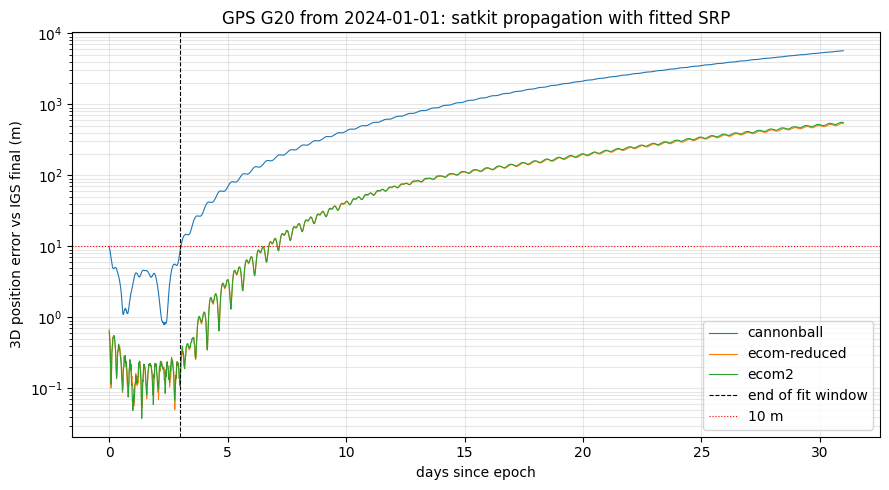

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, (err, _) in results.items():
    ax.plot(tdays, err, lw=0.8, label=name)
ax.axvline(FIT_DAYS, color="k", ls="--", lw=0.8, label="end of fit window")
ax.axhline(10, color="r", ls=":", lw=0.8, label="10 m")
ax.set_yscale("log")
ax.set_xlabel("days since epoch")
ax.set_ylabel("3D position error vs IGS final (m)")
ax.set_title(f"GPS G{PRN:02d} from {START}: satkit propagation with fitted SRP")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## What this shows

* **ECOM is roughly ten times better than the cannonball at every horizon.** Inside the fit arc it tracks the IGS orbit at the decimetre level; a week out it is at ~10 m where the cannonball is at ~150 m.
* **The error is almost entirely along-track** (the T column), growing faster than $t^2$ — the signature of a small, slowly changing acceleration bias.
* **Constant coefficients do not hold for a month.** Refitting over 7 or 14 days instead of 3 lowers the 30-day error (to ~50–150 m) but the *in-window* fit RMS itself grows with window length, and $B_0$ changes sign between windows: the true SRP coefficients drift with the Sun elevation angle above the orbit plane, $\beta$, over weeks. This is exactly why analysis centres re-estimate ECOM daily, and why ECOM2's extra harmonics do not help here — the limitation is temporal, not spectral.

For prediction, therefore, treat ECOM as a **short-arc model**: fit on the most recent few days, expect metre-level accuracy for several days and ~10 m at a week, and refit as new orbits arrive. Rust users can supply per-arc coefficients through `SatProperties::srp_ecom`; from Python, run one `propagate` per arc.

The script `python/examples/ecom_gps_validation.py` in the repository runs this analysis for any PRN, window and fit length from the command line.